# Bivariate OLS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib.font_manager as fm
from matplotlib import ticker
import pyreadr 

In [7]:
plt.rcParams["font.family"] = "Arial"

Figure 3.1 (only the interesting axis due to lack of data)

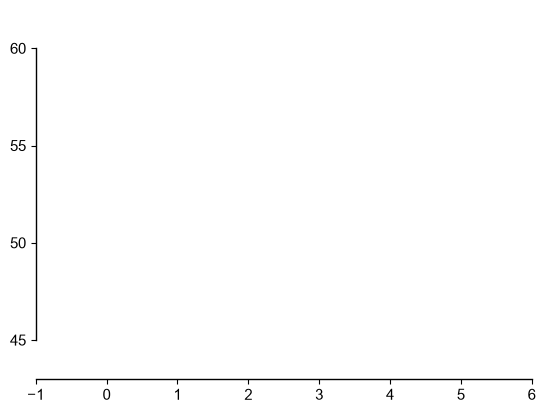

In [16]:
fig, ax = plt.subplots()

ax.set_xlim(-1, 6)
ax.set_ylim(43, 62)

# Ticks
ax.set_xticks(np.arange(-1, 7))
ax.set_yticks([45, 50, 55, 60])

# Remove the extra spines 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# For the broken spine effect 
ax.spines["left"].set_bounds(45, 60)


ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

plt.show()

### Fig 3.4

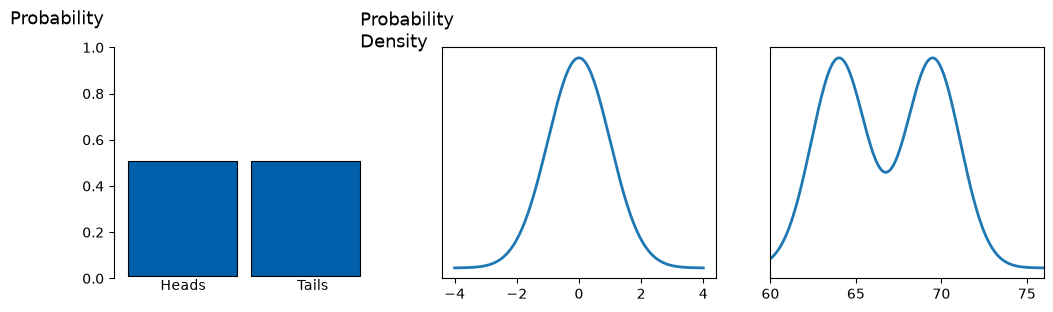

In [ ]:
from matplotlib.patches import Rectangle
from scipy.stats import norm

fig, axes= plt.subplots(1,3, figsize=(12,3))


ax= axes[0]

ax.spines[["bottom", "top", "right"]].set_visible(False)
ax.xaxis.set_major_locator(ticker.NullLocator())
ax.add_patch(Rectangle((0.05,0.01), 0.4, 0.5,
                     edgecolor="black", linewidth=0.8,
                     facecolor= "#0060ac")
)

ax.add_patch(Rectangle((0.5,0.01), 0.4, 0.5,
                     edgecolor="black", linewidth=0.8,
                     facecolor= "#0060ac")
)

ax.text(0.17, -0.05, "Heads")
ax.text(0.67, -0.05, "Tails")
ax.text(-0.38,1.1, "Probability", fontsize=13, transform=ax.transAxes)

ax=axes[1]
ax.yaxis.set_major_locator(ticker.NullLocator())
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, loc=0, scale=1)
ax.text(-0.3,1, "Probability \nDensity", fontsize=13, transform=ax.transAxes)
ax.plot(x, y, lw=2)

ax= axes[2]
ax.yaxis.set_major_locator(ticker.NullLocator())


#A bimodal distribution is just 2 normal distributions added
x = np.linspace(60, 76, 1000)
y = (
    0.5 * norm.pdf(x, loc=64, scale=1.6) +
    0.5 * norm.pdf(x, loc=69.5, scale=1.6)
)

ax.plot(x, y, lw=2)

ax.set_xlim(60, 76)
ax.set_xticks([60, 65, 70, 75])
ax.set_yticks([])

plt.show()

### Figure 3.6

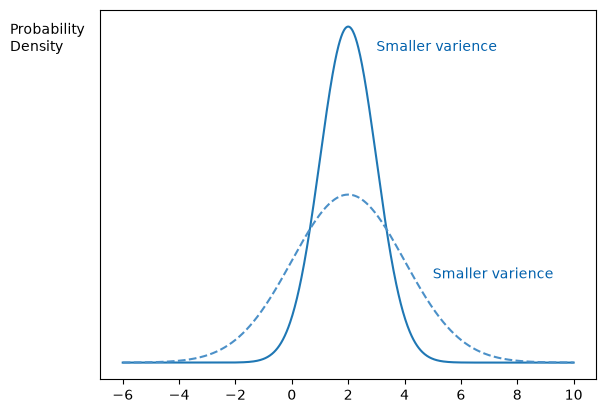

In [153]:
fig, ax= plt.subplots()

x= np.linspace(-6,10,1000)
y= norm.pdf(x, loc=2,scale=1)
z= norm.pdf(x, loc=2,scale=2)

ax.plot(x,y)
ax.plot(x,z, linestyle='--', color= "#4b90c8")

ax.yaxis.set_major_locator(ticker.NullLocator())

ax.text(-10, 0.37, "Probability \nDensity")
ax.text(3, 0.37, "Smaller varience", color="#0060ac" )
ax.text(5, 0.1, "Smaller varience", color="#0060ac" )

plt.show()

Other figures are just the same or lack data

# Computing Corner

I will be using StatsModels library for the econometrics application 

In [104]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

 We will import the donut data we cleaned in the chapter 2

In [ ]:
DonutDF= pd.read_csv(r"filepath\donuts.csv")
display(DonutDF.head())

,name,donuts,weight,child,male
0,Homer,14.0,275.0,0.0,0.0
1,Marge,0.0,141.0,0.0,1.0
2,Lisa,0.0,70.0,1.0,1.0
3,Bart,5.0,75.0,1.0,0.0
4,Comic Book Guy,20.0,310.0,0.0,0.0


In [212]:
DonutDF.info()
# donutsx is a string and I remember from chapter 2 that there is a random "5" in "donutsx"

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    13 non-null     str    
 1   donuts  13 non-null     float64
 2   weight  13 non-null     float64
 3   child   13 non-null     float64
 4   male    13 non-null     float64
dtypes: float64(4), str(1)
memory usage: 652.0 bytes


**1.** 

Python and R both are object oriented programming languages,(though python can allow functional programming), and statsmodels also saves the information about the regression into an that object we can name. And we will name the object, DonutOLS. The syntax of statsmodels.formula (smf) is quite similar to the one in R. We have to call smf and in that the function ols. The formula is straight forward with dependent variable ~ independent variable. We will go deeper into what is python doing here but in general statsmodels.formula is at a higher level than statsmodel (sm) which is not important to get into right now, but yes eventually sm is more hands on and gives you more control but smf does what we need right now.

In [232]:
DonutOLS= smf.ols(

 # With formula we let python know that we want a model with donuts as a linear function of weightx 
 # Meaning weightx= β0 + β1 donutsx + μ 
 # But right now Python does not know what β0 and β1 are        
        formula= "weight ~ donuts",
        data=DonutDF
        
# Now the .fit() is what tells python that it should find βs which best fit the data
# So python is running the minimization of ∑(yi-ŷi)²
).fit()


print(DonutOLS.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     22.16
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           0.000643
Time:                        01:07:10   Log-Likelihood:                -67.080
No. Observations:                  13   AIC:                             138.2
Df Residuals:                      11   BIC:                             139.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    121.6134     16.593      7.329      0.0

If it helps we can also do which makes the process more explicit
* We make a model
* Tell python to fit it
* Get the results

`model=smf.ols("y~x", data=df)`

`results=model.fit()`

`print(results.summery())`

It is weird that the results we are getting are different from what the book gets, but this could be a data change on the author's side.

statsmodel does not show the standard error of regression (̂σ), to get it we have to do, √DonutOLS.scale as .scale gives the Variance of regression or Mean square error (MSE) and it's root will give standard error of regression or as it is called in R Residual Standard Error

In [216]:
print(DonutOLS.scale, "This is the Variance of Regression")
print(np.sqrt(DonutOLS.scale), "This is the Standard error of Error")

2098.9071455265253 This is the Variance of Regression
45.81383137794224 This is the Standard error of Error


**2**

Other information that R creates is almost identical to what statsmodel makes and can be accessed in the same way

In [ ]:
display(DonutOLS.fittedvalues)
display(DonutOLS.resid)


0     250.742775
1     121.613413
2     121.613413
3     167.731042
4     306.083931
5     128.531057
6     123.919294
7     269.189827
8     149.283990
9     140.060465
10    128.992234
11    167.731042
12    158.507516
dtype: float64

0     24.257225
1     19.386587
2    -51.613413
3    -92.731042
4      3.916069
5    -48.531057
6     36.080706
7     -6.189827
8     55.716010
9     44.939535
10    41.007766
11   -12.731042
12   -13.507516
dtype: float64

In [ ]:
# Unfortunately statsmodel or python does not have
# A help(lm) type command, the closest we do have is dir
# This gives us all the things we can perform after writing DonutOLS

dir(DonutOLS)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'diagn',
 'eigenvals',
 'el_test',
 'ess',
 'f_pval

**3.**

Scatterplot can be made by the normal route but we have to use DonutOLS parameters to plot the regression line



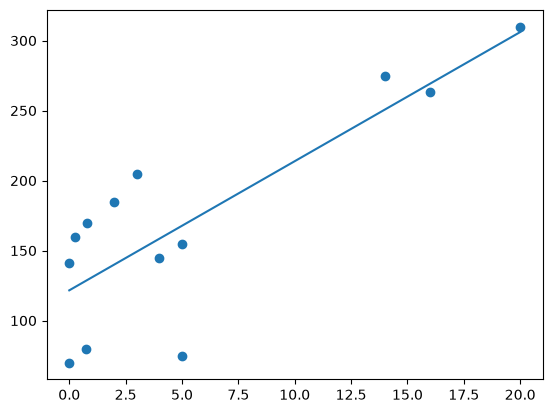

In [ ]:
fig, ax = plt.subplots()

ax.scatter(DonutDF["donuts"], DonutDF["weight"])

# Regression line
x = np.linspace(DonutDF["donuts"].min(),DonutDF["donuts"].max(),200)
y = DonutOLS.params["Intercept"] + DonutOLS.params["donuts"] * x

#It is perfectly fine to use x= Donuts["donuts"] because this is ols, the model is linear
#But in other models like quadratic splitting x from its min to max into even points will make the plot look smooth 
#So this is more of a habit building thing

ax.plot(x, y)

plt.show()


**4.**

We can exclude observations by performing pandas slicing conditions to the `data=` part of our OLS formula

In [ ]:
results = smf.ols(
    "weight ~ donuts",
    data=DonutDF[DonutDF["name"] != "Homer"]
).fit()

In [ ]:
results = smf.ols(
    "weight ~ donuts",
    data=DonutDF[DonutDF["weight"] > 100]
).fit()

In [ ]:
results = smf.ols(
    "weight ~ donuts",
    data=DonutDF[
        (DonutDF["weight"] > 100) &
        (DonutDF["name"] != "Homer")]
).fit()

**5.**

To find out $Var(\hat{\beta})$ we use a formula which depends on the fact that there is homoskedasticity but White(1980) showed that we can estimate  $Var(\hat{\beta})$ without the assumption, I will not go into what the method entails but to evoke that method in our estimations we don't need a new library like in R, we have it in statsmodel itself:

In [235]:
DonutOLS = smf.ols(
    "weight ~ donuts",
    data=DonutDF
).fit()

robust_DonutOLS = DonutOLS.get_robustcov_results(cov_type="HC1")
print(robust_DonutOLS.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     69.67
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           4.35e-06
Time:                        01:26:03   Log-Likelihood:                -67.080
No. Observations:                  13   AIC:                             138.2
Df Residuals:                      11   BIC:                             139.3
Df Model:                           1                                         
Covariance Type:                  HC1                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    121.6134     17.256      7.048      0.0

In [ ]:
# we can also

DonutOLS = smf.ols(
    "weight ~ donuts",
    data=DonutDF
).fit(cov_type="HC1")

# Excercises 

# 1

In [ ]:
rdt= pyreadr.read_r(r"filepath")
voteDF= rdt["dta"]
display(voteDF.head())
display(voteDF.info())

,year,term,IncumbentPartyNominee,war,vote,timeperiod,Reelection,DemIncumbentParty,demcand,repcand,...,yrinfq3,yrinfyr,yrinfprevyr,stock,unemploymentq3,avglaborforcepart,avglaborforcepartprevyr,avglaborforcepartytd,laborforcepartq3,gallupapprovq3
0,1948.0,4.0,Truman,0.0,0.523695,1.0,1.0,1.0,Truman,Dewey,...,6.654991,2.733874,8.883721,4.789644,3.7,58.841667,NaN,58.830002,58.700001,40.0
1,1952.0,5.0,Stevenson,1.0,0.445481,2.0,0.0,1.0,Stevenson,Eisenhower,...,2.305033,0.906687,5.964772,3.852740,3.0,59.058334,59.283333,59.040001,58.700001,33.0
2,1956.0,1.0,Ike,0.0,0.577516,3.0,1.0,0.0,Stevenson,Eisenhower,...,1.862197,2.828433,0.373552,9.807647,3.9,59.966667,59.224998,60.000000,59.799999,68.0
3,1960.0,2.0,Nixon60,0.0,0.499174,4.0,0.0,0.0,Kennedy,Nixon,...,1.230769,1.360082,1.518813,-5.736842,6.1,59.416668,59.275002,59.349998,59.400002,65.0
4,1964.0,1.0,LBJ,0.0,0.613447,5.0,1.0,1.0,Johnson,Goldwater,...,1.171875,1.198187,1.645820,16.185129,5.1,58.716667,58.658333,58.750000,58.599998,74.0


<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     18 non-null     float64
 1   term                     18 non-null     float64
 2   IncumbentPartyNominee    18 non-null     str    
 3   war                      18 non-null     float64
 4   vote                     18 non-null     float64
 5   timeperiod               18 non-null     float64
 6   Reelection               18 non-null     float64
 7   DemIncumbentParty        18 non-null     float64
 8   demcand                  18 non-null     str    
 9   repcand                  18 non-null     str    
 10  ChangeRealDspIncPerCap   18 non-null     float64
 11  rdi4                     17 non-null     float64
 12  avgunemployment          18 non-null     float64
 13  avgunemploymentprevyr    18 non-null     float64
 14  avgunemploymentytd       18 non-null   

None

### a

In [ ]:
# On the plot we will get 1990.0 if we don't convert it into int

voteDF["year"]= voteDF["year"].astype(int)

Text(0.5, 0, 'Percentage change in income')

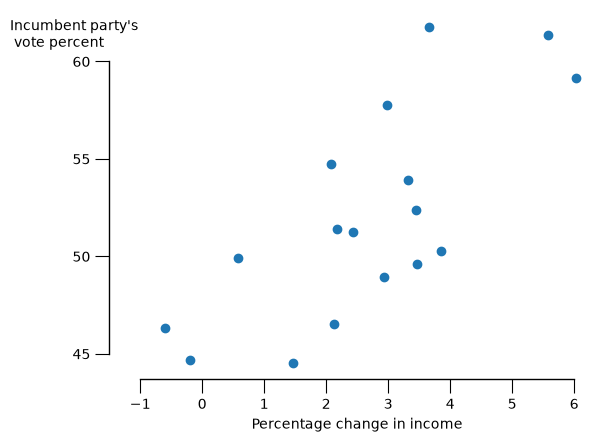

In [100]:
fig, ax= plt.subplots()

ax.scatter(voteDF["rdi4"], voteDF["vote"]*100) # Times 100 to get percentage

#matplotlib does not have an automatic label system like excel or R so we have to make a loop

for _, rows in voteDF.iterrows():
    # After some iterations 2004 was getting overlapped so we make an if statement to move it only
    if rows["year"]==2004:
        offset=(5,5)
    else:
        offset=(-20,6)
                #label, position
    ax.annotate(rows["year"], (rows["rdi4"], rows["vote"]),
    # textcoord decides how xytext behaves, offset points makes xytext=(a,b) shift the text a points right and b  points up
                color= "black", xytext=offset, textcoords="offset points",
    )

# Removed the spines and set the spine bound
ax.spines[["top","right"]].set_visible(False)
ax.spines["left"].set_bounds(45,60)
ax.spines["bottom"].set_bounds(-1,6)

#Customization
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)
ax.tick_params(axis="both", length=10)

#Set the ticks that should show, also setting xlim gives you power to make the axis shift and with fixed locator the extra points dont show up
ax.xaxis.set_major_locator(ticker.FixedLocator([-1,0,1,2,3,4,5,6]))
ax.set_xlim(-1.5,6.5)
ax.yaxis.set_major_locator(ticker.FixedLocator([45,50,55,60]))

ax.text(-0.2,0.90, "Incumbent party's \n vote percent", transform=ax.transAxes)
ax.set_xlabel("Percentage change in income")

### b

In [ ]:
voteOLS= smf.ols(
    formula= "vote ~ rdi4",         #Dependent regressed on Independent
    data=voteDF
).fit()

print(voteOLS.summary())

                            OLS Regression Results                            
Dep. Variable:                   vote   R-squared:                       0.554
Model:                            OLS   Adj. R-squared:                  0.524
Method:                 Least Squares   F-statistic:                     18.63
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           0.000611
Time:                        05:31:53   Log-Likelihood:                 32.757
No. Observations:                  17   AIC:                            -61.51
Df Residuals:                      15   BIC:                            -59.85
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4591      0.017     27.234      0.0

### c

In [115]:
voteDF["fitted"] = voteOLS.fittedvalues
display(voteDF.loc[voteDF["year"].isin([1996, 1972]), ["year", "vote", "fitted"]])

,year,vote,fitted
6,1972,0.617861,0.543058
12,1996,0.547353,0.506748


### e

In [116]:
voteDF["residual"] = voteOLS.resid
voteDF.loc[
    voteDF["year"].isin([1996, 1972]),
    ["year", "vote", "fitted", "residual"]
]

,year,vote,fitted,residual
6,1972,0.617861,0.543058,0.074803
12,1996,0.547353,0.506748,0.040605


### f

In [117]:
voteOLS= smf.ols(
    formula= "vote ~ rdi4",        
    data=voteDF[voteDF["Reelection"]==1]
).fit()

print(voteOLS.summary())

                            OLS Regression Results                            
Dep. Variable:                   vote   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     16.12
Date:                Sat, 04 Jul 2026   Prob (F-statistic):            0.00510
Time:                        05:48:51   Log-Likelihood:                 19.068
No. Observations:                   9   AIC:                            -34.14
Df Residuals:                       7   BIC:                            -33.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4717      0.022     21.191      0.0

# 2

The code given is a pure R code and not a dataset, so I will be manually converting it.

In [127]:
#Number of people and the times we will do this simulation
Obs = 100
Reps = 50

# Model parameters
TrueBeta0 = 12000
TrueBeta1 = 1000
sd = 10000

#Generate education, this makes an array of numbers starting from 0 to 16, and a total of obs= 100 times
Ed = np.random.uniform(0, 16, Obs) #Each of our people(obs) get a number from 0 to 16 which acts as education

# Matrix to store estimated coefficients
CoefMatrix = np.empty((Reps, 2)) #We are telling python to save the memory for an array of Reps=50 rows and 2 columns 
#2 columns to store intercept and slope and total of 50 times as we will run this 50 times and each time get 1 slope and 1 intercept


# In the R code, author has simulated salary in each repetition but education is only simulated once, hence the loop only has salary while education is outside

for i in range(Reps): #All of following is now being done 50 times, so 50 salaries and 50 regressions and 50 saves to CoefMatrix

# We simulate the salary. np(size=obs) is an array of 100 numbers taken from the normal distribution
# Other things are now added to this array to give us an array of values that act as salary to our 100 people

                #Though against the convention, writing the error term first makes it clear for me, we make an array and then add things to it 
    Salary= np.random.normal(scale=sd, size=Obs) + TrueBeta0+ TrueBeta1 * Ed 
    
    model= smf.ols(
        formula="Salary ~ Ed",
        data=pd.DataFrame({"Salary": Salary, "Ed": Ed})
    ).fit()

# .params is Intercept, Slope, we store that information into the array that we made
    CoefMatrix[i] = model.params

print("Intercept")
print("Mean:", CoefMatrix[:, 0].mean())     #Intercept as mentioned is the first column of .param and is saved so in CoefMatrix so :,0 is all rows of column zero
print("Min :", CoefMatrix[:, 0].min())
print("Max :", CoefMatrix[:, 0].max())

print()

print("Slope")
print("Mean:", CoefMatrix[:, 1].mean())
print("Min :", CoefMatrix[:, 1].min())
print("Max :", CoefMatrix[:, 1].max())

Intercept
Mean: 11896.999159117842
Min : 7528.4715617068605
Max : 16765.07653192066

Slope
Mean: 1000.5867427816816
Min : 487.50971997169916
Max : 1564.1675163218338


In [128]:
# Opening out arrays and things can help understand what is being stored in them

OLSdata=pd.DataFrame({"Salary": Salary, "Ed": Ed})
display(OLSdata.head(10))

,Salary,Ed
0,13895.353554,10.574280
1,35993.422121,12.051498
2,10550.023037,4.990120
3,12925.090292,3.641648
4,36578.011284,9.043438
5,24023.289435,8.256138
6,9049.327158,1.280031
7,22432.087453,0.112316
8,11534.456207,9.012792
9,32735.602906,5.009611


The idea is simple

* Give the number of people (obs) and repetitions
* Give true values of beta
* Add errors to the variables both dependent and independent
* Save in an array because otherwise with each loop the old data will get written over

### a

The estimated coefficients vary from simulation to simulation because each simulated dataset contains different random errors, making the OLS estimates random variables. Since OLS is an unbiased estimator, the expected value of the estimated coefficients equals the true coefficients. Therefore, when we average the estimates over many simulations, the sample mean of the estimated coefficients is very close to the true parameter values. If the error terms are normally distributed (or the sample is sufficiently large), the sampling distribution of the estimated coefficients is also approximately normal, which explains why estimates close to the true value occur more frequently than estimates far away.

### b

The min and max values are quite far from the true values which is natural, the estimated coefficients follow a distribution and getting values some standard deviation away from the true values does not change that fact that OLS is unbiased and over multiple simulations the expected value will be equal to real β     

### c

In [144]:
#Number of people and the times we will do this simulation
Obs = 1000
Reps = 50

# Model parameters
TrueBeta0 = 12000
TrueBeta1 = 1000
sd = 10000

#Generate education, this makes an array of numbers starting from 0 to 16, and a total of obs= 100 times
Ed = np.random.uniform(0, 16, Obs) #Each of our people(obs) get a number from 0 to 16 which acts as education

# Matrix to store estimated coefficients
CoefMatrix = np.empty((Reps, 2)) #We are telling python to save the memory for an array of Reps=50 rows and 2 columns 
#2 columns to store intercept and slope and total of 50 times as we will run this 50 times and each time get 1 slope and 1 intercept


# In the R code, author has simulated salary in each repetition but education is only simulated once, hence the loop only has salary while education is outside

for i in range(Reps): #All of following is now being done 50 times, so 50 salaries and 50 regressions and 50 saves to CoefMatrix

# We simulate the salary. np(size=obs) is an array of 100 numbers taken from the normal distribution
# Other things are now added to this array to give us an array of values that act as salary to our 100 people

                #Though against the convention, writing the error term first makes it clear for me, we make an array and then add things to it 
    Salary= np.random.normal(scale=sd, size=Obs) + TrueBeta0+ TrueBeta1 * Ed 
    
    model= smf.ols(
        formula="Salary ~ Ed",
        data=pd.DataFrame({"Salary": Salary, "Ed": Ed})
    ).fit()

# .params is Intercept, Slope, we store that information into the array that we made
    CoefMatrix[i] = model.params

print("Intercept")
print("Mean:", CoefMatrix[:, 0].mean())     #Intercept as mentioned is the first column of .param and is saved so in CoefMatrix so :,0 is all rows of column zero
print("Min :", CoefMatrix[:, 0].min())
print("Max :", CoefMatrix[:, 0].max())

print()

print("Slope")
print("Mean:", CoefMatrix[:, 1].mean())
print("Min :", CoefMatrix[:, 1].min())
print("Max :", CoefMatrix[:, 1].max())

Intercept
Mean: 12338.75550443377
Min : 11429.656227187526
Max : 13467.63236390838

Slope
Mean: 976.6511595431919
Min : 838.9291582587487
Max : 1116.3004956911589


The minimum and maximum estimated coefficients are much closer to the true value than in the smaller sample. This is because increasing the sample size reduces the variance (and hence the standard error) of the OLS estimator. With more observations, random errors average out more effectively, causing the sampling distribution of the estimated coefficients to become more concentrated around the true parameter. Consequently, extreme estimates become less likely, making the estimates more precise. This showcases the consistence property of OLS, with larger samples the max and min come closer 

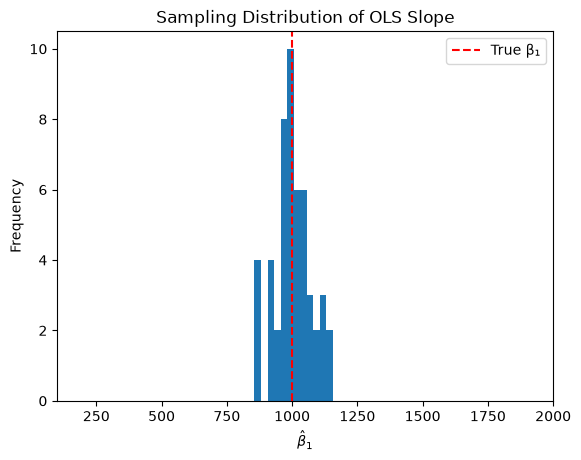

In [138]:
# visually 

plt.hist(CoefMatrix[:, 1], bins=12)

plt.axvline(TrueBeta1, color="red", linestyle="--", label="True β₁")

plt.xlabel(r"$\hat{\beta}_1$")
plt.xlim(100,2000)
plt.ylabel("Frequency")
plt.title("Sampling Distribution of OLS Slope")
plt.legend()

plt.show()

### d

In [139]:
#Number of people and the times we will do this simulation
Obs = 20
Reps = 50

# Model parameters
TrueBeta0 = 12000
TrueBeta1 = 1000
sd = 10000

#Generate education, this makes an array of numbers starting from 0 to 16, and a total of obs= 100 times
Ed = np.random.uniform(0, 16, Obs) #Each of our people(obs) get a number from 0 to 16 which acts as education

# Matrix to store estimated coefficients
CoefMatrix = np.empty((Reps, 2)) #We are telling python to save the memory for an array of Reps=50 rows and 2 columns 
#2 columns to store intercept and slope and total of 50 times as we will run this 50 times and each time get 1 slope and 1 intercept


# In the R code, author has simulated salary in each repetition but education is only simulated once, hence the loop only has salary while education is outside

for i in range(Reps): #All of following is now being done 50 times, so 50 salaries and 50 regressions and 50 saves to CoefMatrix

# We simulate the salary. np(size=obs) is an array of 100 numbers taken from the normal distribution
# Other things are now added to this array to give us an array of values that act as salary to our 100 people

                #Though against the convention, writing the error term first makes it clear for me, we make an array and then add things to it 
    Salary= np.random.normal(scale=sd, size=Obs) + TrueBeta0+ TrueBeta1 * Ed 
    
    model= smf.ols(
        formula="Salary ~ Ed",
        data=pd.DataFrame({"Salary": Salary, "Ed": Ed})
    ).fit()

# .params is Intercept, Slope, we store that information into the array that we made
    CoefMatrix[i] = model.params

print("Intercept")
print("Mean:", CoefMatrix[:, 0].mean())     #Intercept as mentioned is the first column of .param and is saved so in CoefMatrix so :,0 is all rows of column zero
print("Min :", CoefMatrix[:, 0].min())
print("Max :", CoefMatrix[:, 0].max())

print()

print("Slope")
print("Mean:", CoefMatrix[:, 1].mean())
print("Min :", CoefMatrix[:, 1].min())
print("Max :", CoefMatrix[:, 1].max())

Intercept
Mean: 12470.133689621736
Min : 2332.038625519909
Max : 23331.743703939734

Slope
Mean: 974.2123859366303
Min : 100.2808608151111
Max : 2314.9115377272246


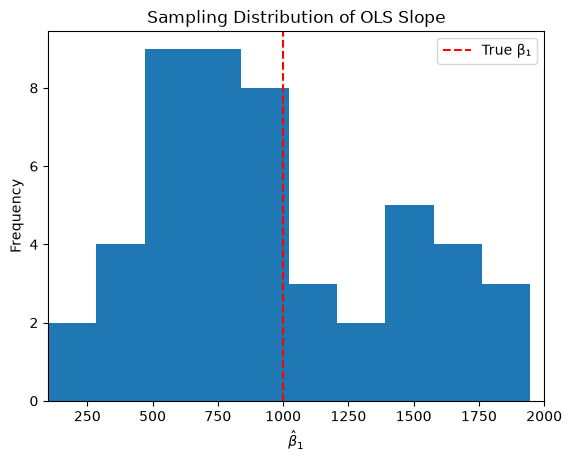

In [143]:
plt.hist(CoefMatrix[:, 1], bins=12)

plt.axvline(TrueBeta1, color="red", linestyle="--", label="True β₁")

plt.xlabel(r"$\hat{\beta}_1$")
plt.ylabel("Frequency")
plt.xlim(100,2000)
plt.title("Sampling Distribution of OLS Slope")
plt.legend()

plt.show()

Next few problems are just changes to the error term, that can be done by changing the `scale=` in the error terms
 

### m

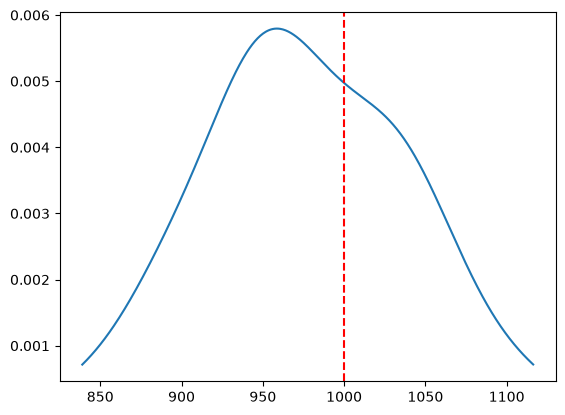

In [ ]:
# This is for the original simulation

import scipy.stats as stats

x = np.linspace(
    CoefMatrix[:,1].min(),
    CoefMatrix[:,1].max(),
    500
)

#Think of kernel density as joining the peaks of histogram
#WE feed our intercepts to the function and it makes a smooth distribution from the data (joining the peaks of histogram)
kde = stats.gaussian_kde(CoefMatrix[:,1])


#Now here kde returns the values of the density function for all the points that x has (x is just 500 equal points between min and max of β)
plt.plot(x, kde(x))

plt.axvline(TrueBeta1,
            color="red",
            linestyle="--")

plt.show()

# 3

In [146]:
rdt= pyreadr.read_r(r"C:\Users\khosl\OneDrive\Documents\Py notebook\Books\Real Econometrics\RE2e_Exercise Data_CH03\RE2e_R Data sets_CH03\Ch3_Exercise3_Height_and_Wages_UK.RData")
HiWeDF= rdt["dta"]
display(HiWeDF.head())

,male,height33,gwage33
0,1.0,66.929131,12.428572
1,1.0,70.078743,7.027027
2,1.0,70.078743,5.121951
3,1.0,68.897636,8.333333
4,1.0,66.141731,11.333333


### a

In [165]:
model= smf.ols(
    formula="gwage33 ~ height33",
    data= HiWeDF
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                gwage33   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.941
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.164
Time:                        23:13:12   Log-Likelihood:                -19289.
No. Observations:                3696   AIC:                         3.858e+04
Df Residuals:                    3694   BIC:                         3.859e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.5994     12.214     -0.540      0.5

### b

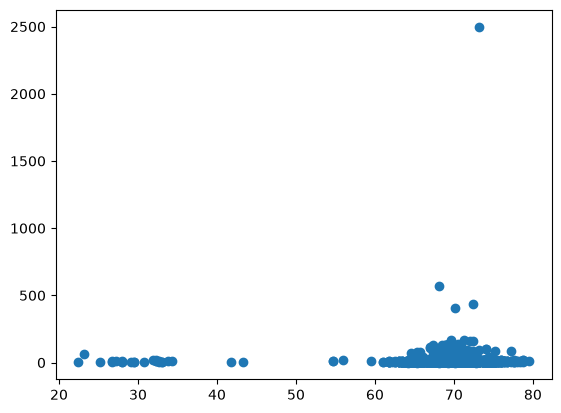

In [154]:
plt.scatter(HiWeDF["height33"], HiWeDF["gwage33"])
plt.show()

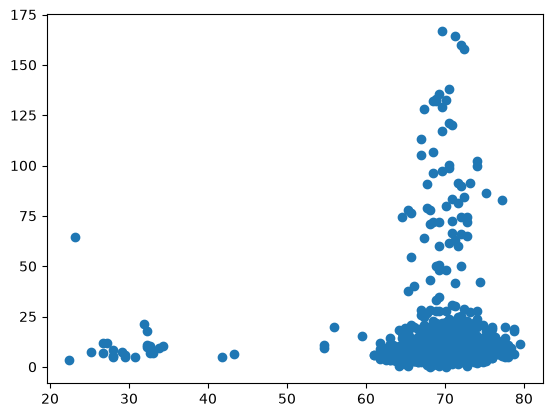

In [ ]:
# The questions says AND but and makes the observations down to 23 only so 
# I think it might be a misprint as then question e is not possible

HiWeDF_ol= HiWeDF[(HiWeDF["height33"]<40) | (HiWeDF["gwage33"]<400)]

plt.scatter(HiWeDF_ol["height33"], HiWeDF_ol["gwage33"])
plt.show()

### d

In [178]:
model= smf.ols(
    formula="gwage33 ~ height33",
    data= HiWeDF_ol
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                gwage33   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.209
Date:                Sat, 04 Jul 2026   Prob (F-statistic):             0.0733
Time:                        23:27:36   Log-Likelihood:                -14431.
No. Observations:                3692   AIC:                         2.887e+04
Df Residuals:                    3690   BIC:                         2.888e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4461      3.296      1.046      0.2

### e

In [179]:
model= smf.ols(
    formula="gwage33 ~ height33",
    data= HiWeDF_ol.head(800)
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                gwage33   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.329
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.127
Time:                        23:27:39   Log-Likelihood:                -3065.8
No. Observations:                 800   AIC:                             6136.
Df Residuals:                     798   BIC:                             6145.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.9782      7.088     -0.279      0.7

3692

3696